In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

# List what's in Drive root
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Getting started.pdf',
 'Classroom',
 'z043-mayurthote.pdf',
 'mayurpassbook.pdf',
 'Mayur photo.JPG',
 'Business Intelligence & Reporting Analyst (Power BI  SAP BusinessObjects  SQL)_Mayur Thote (5).pdf',
 'Business Intelligence & Reporting Analyst (Power BI  SAP BusinessObjects  SQL)_Mayur Thote (4).pdf',
 'Business Intelligence & Reporting Analyst (Power BI  SAP BusinessObjects  SQL)_Mayur Thote (3).pdf',
 'Business Intelligence & Reporting Analyst (Power BI  SAP BusinessObjects  SQL)_Mayur Thote (2).pdf',
 'Business Intelligence & Reporting Analyst (Power BI  SAP BusinessObjects  SQL)_Mayur Thote (1).pdf',
 'Business Intelligence & Reporting Analyst (Power BI  SAP BusinessObjects  SQL)_Mayur Thote.pdf',
 'FFA Day-4 Resources.pdf',
 'FFA Day-3 Resources.pdf',
 'FFA Day-1 Resources.pdf',
 'Prompt to Fetch Data.pdf',
 'FFA Day-2 Resources.pdf',
 'Chartink Guide Bullish.pdf',
 'Chartink Guide Bearish.pdf',
 'BI & Reporting Analyst_Mayur Thote (1).pdf',
 'BI & Repor

In [9]:
BASE_PATH = '/content/drive/MyDrive/'

print("images folder exists :", os.path.exists(os.path.join(BASE_PATH, 'images')))
print("labels.csv  exists  :", os.path.exists(os.path.join(BASE_PATH, 'labels.csv')))

images folder exists : True
labels.csv  exists  : True


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
os.makedirs('/content/results', exist_ok=True)
os.makedirs('/content/sample_predictions', exist_ok=True)

TensorFlow version: 2.20.0


Task1: Problem identification

problem type = "Image Classification

Why Image Classification?
- Each image belongs to exactly ONE category:
  normal, scratch, dent, or stain.
- The goal is to assign a single class label to each input image.
- There are no bounding boxes (ruling out Object Detection),
  no pixel-level masks (ruling out Semantic Segmentation),
  and no instance-level distinctions (ruling out Instance Segmentation).
- A CNN classifier with a softmax output layer perfectly fits this problem.

In [11]:
# TASK 2: Dataset Exploration

# Load CSV
df = pd.read_csv(os.path.join(BASE_PATH, 'labels.csv'))

# Fix paths to be absolute (prepend BASE_PATH)
# CSV already has paths like: images/normal/normal_001.png
df['filepath'] = df['filename'].apply(lambda x: os.path.join(BASE_PATH, x))
df.columns = ['filename', 'label', 'filepath']

print("Total images :", len(df))
print("Classes      :", df['label'].unique().tolist())
print("Shape        :", df.shape)
print("\nImages per class:")
print(df['label'].value_counts())

Total images : 480
Classes      : ['normal', 'scratch', 'dent', 'stain']
Shape        : (480, 3)

Images per class:
label
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


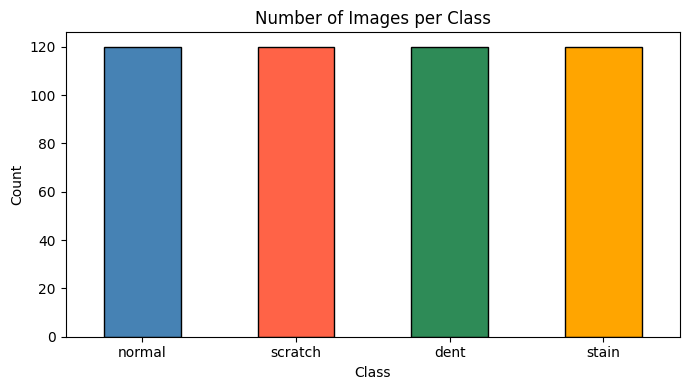

Class distribution is BALANCED — 120 images per class.


In [12]:
# Class distribution bar chart
df['label'].value_counts().plot(
    kind='bar', color=['steelblue','tomato','seagreen','orange'],
    figsize=(7, 4), edgecolor='black'
)
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/results/class_distribution.png', dpi=150)
plt.show()
print("Class distribution is BALANCED — 120 images per class.")

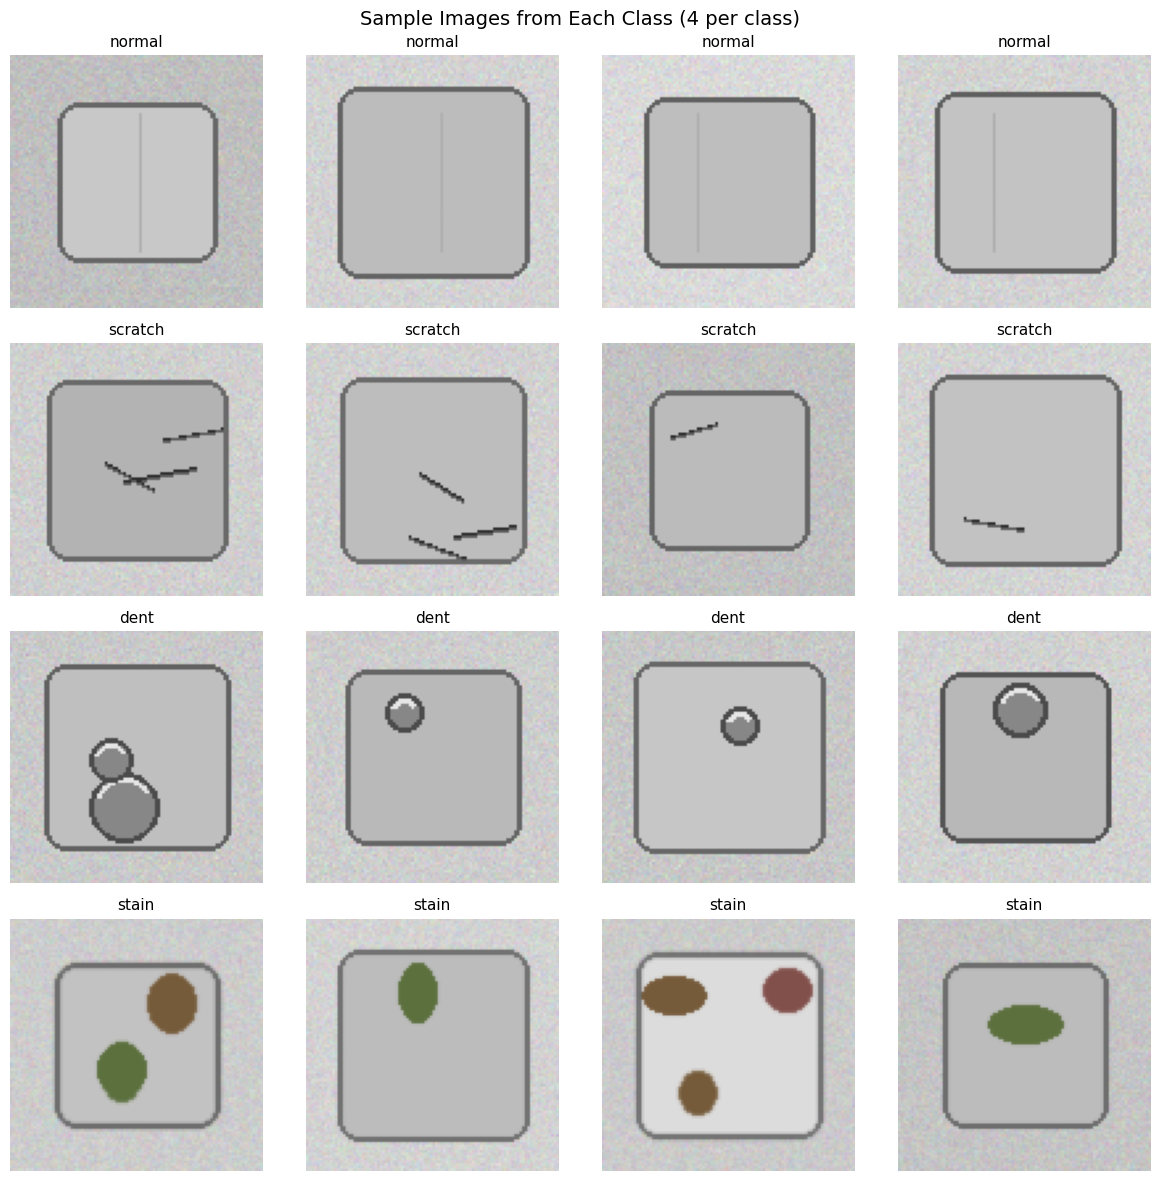

In [13]:
# Check image dimensions and display sample images from each class
CLASS_NAMES = ['normal', 'scratch', 'dent', 'stain']

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, cls in enumerate(CLASS_NAMES):
    class_df = df[df['label'] == cls]
    samples  = class_df.sample(4, random_state=42)['filepath'].tolist()
    for col, img_path in enumerate(samples):
        img = mpimg.imread(img_path)
        axes[row][col].imshow(img)
        axes[row][col].set_title(f'{cls}', fontsize=11)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12)

plt.suptitle('Sample Images from Each Class (4 per class)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/results/sample_images.png', dpi=150)
plt.show()

In [14]:
# Check actual image dimensions
from PIL import Image

sample_path = df['filepath'].iloc[0]
img = Image.open(sample_path)
print(f"Sample image size   : {img.size}  (width x height)")
print(f"Mode                : {img.mode}")
print(f"Sample image path   : {sample_path}")

Sample image size   : (96, 96)  (width x height)
Mode                : RGB
Sample image path   : /content/drive/MyDrive/images/normal/normal_001.png


In [15]:
# TASK 3: Image Preprocessing

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Train / Val / Test split: 70% / 15% / 15%
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print(f"Train      : {len(train_df)} images")
print(f"Validation : {len(val_df)} images")
print(f"Test       : {len(test_df)} images")

Train      : 336 images
Validation : 72 images
Test       : 72 images


In [16]:
# Training generator — with augmentation
train_datagen = ImageDataGenerator(
    rescale            = 1./255,       # normalize pixels to [0, 1]
    rotation_range     = 20,           # random rotation up to 20°
    width_shift_range  = 0.1,          # horizontal shift
    height_shift_range = 0.1,          # vertical shift
    horizontal_flip    = True,         # flip left-right
    zoom_range         = 0.1,          # slight zoom
    shear_range        = 0.1           # shear transformation
)

# Val and Test generators — only normalize, no augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_gen = train_datagen.flow_from_dataframe(
    dataframe   = train_df,
    x_col       = 'filepath',
    y_col       = 'label',
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe   = val_df,
    x_col       = 'filepath',
    y_col       = 'label',
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe   = test_df,
    x_col       = 'filepath',
    y_col       = 'label',
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

print("\nClass indices:", train_gen.class_indices)

Found 336 validated image filenames belonging to 4 classes.
Found 72 validated image filenames belonging to 4 classes.
Found 72 validated image filenames belonging to 4 classes.

Class indices: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


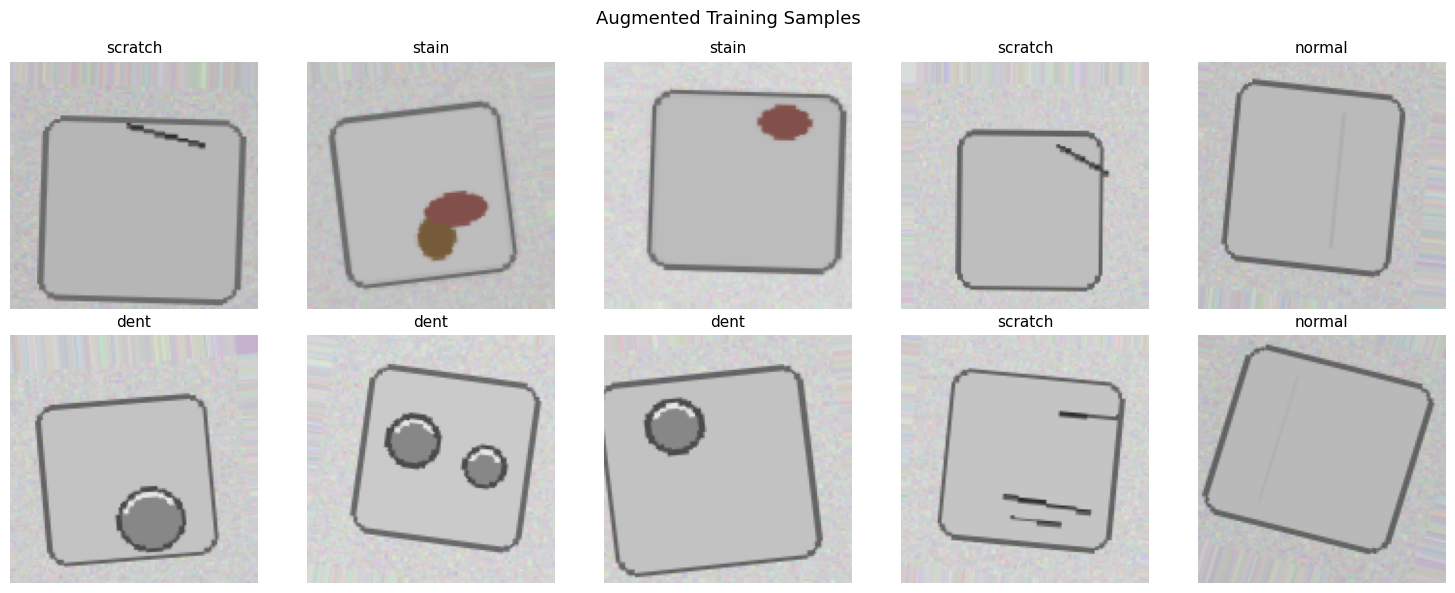

In [17]:
# Visualize augmented training images
sample_images, sample_labels = next(train_gen)
class_names = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i])
    ax.set_title(class_names[np.argmax(sample_labels[i])], fontsize=11)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# ── TASK 4: CNN Model Creation ───────────────────────────────────

NUM_CLASSES = 4

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
], name='cnn_surface_defect')

model.summary()

Model: "cnn_surface_defect"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,196 (16.36 MB)

 Trainable params: 4,288,196 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled.")
print("  Loss      : Categorical Cross-Entropy")
print("  Optimizer : Adam (lr=0.0001)")

Model compiled.
  Loss      : Categorical Cross-Entropy
  Optimizer : Adam (lr=0.0001)


In [30]:
# TASK 5: Training

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,               # was 10
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.2500 - loss: 1.4046 - val_accuracy: 0.2500 - val_loss: 1.3908 - learning_rate: 1.0000e-04
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2679 - loss: 1.3988 - val_accuracy: 0.2917 - val_loss: 1.3844 - learning_rate: 1.0000e-04
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.2679 - loss: 1.3965 - val_accuracy: 0.2639 - val_loss: 1.3813 - learning_rate: 1.0000e-04
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2411 - loss: 1.3930 - val_accuracy: 0.2500 - val_loss: 1.3784 - learning_rate: 1.0000e-04
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2738 - loss: 1.3827 - val_accuracy: 0.3333 - val_loss: 1.3735 - learning_rate: 1.0000e-04
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.3065 - loss: 1.3777 - val_accuracy: 0.5000 - val_loss: 1.3667 - learning_rate: 1.0000e-04
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.2798 

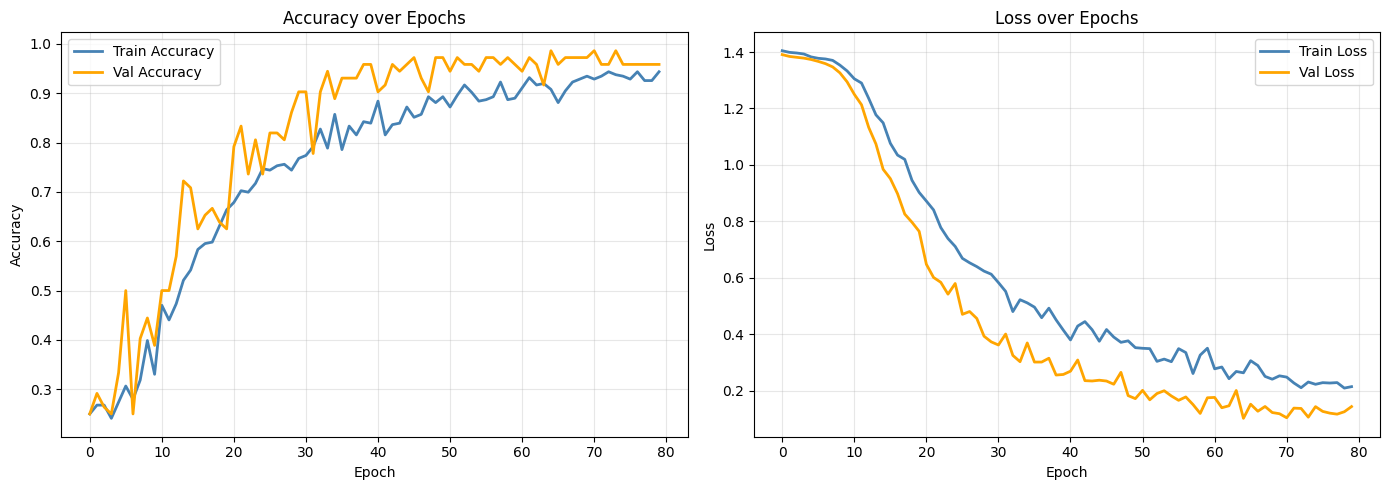

[Saved] /content/results/accuracy_loss_curves.png


In [31]:
# Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange',    linewidth=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange',    linewidth=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/accuracy_loss_curves.png', dpi=150)
plt.show()
print("[Saved] /content/results/accuracy_loss_curves.png")

In [32]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 98.61%
Test Loss     : 0.1103


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step
Classification Report:
              precision    recall  f1-score   support

        dent       1.00      1.00      1.00        18
      normal       0.95      1.00      0.97        18
     scratch       1.00      0.94      0.97        18
       stain       1.00      1.00      1.00        18

    accuracy                           0.99        72
   macro avg       0.99      0.99      0.99        72
weighted avg       0.99      0.99      0.99        72



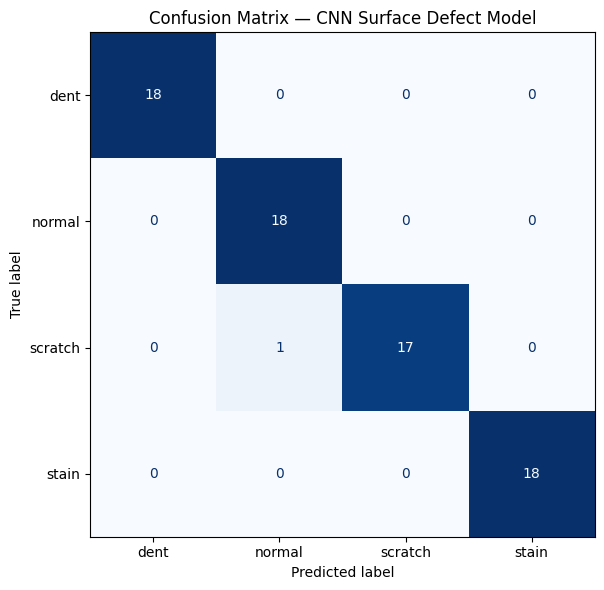

[Saved] /content/results/confusion_matrix.png


In [33]:
# Classification report + confusion matrix
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — CNN Surface Defect Model')
plt.tight_layout()
plt.savefig('/content/results/confusion_matrix.png', dpi=150)
plt.show()
print("[Saved] /content/results/confusion_matrix.png")

Found 10 validated image filenames belonging to 4 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step


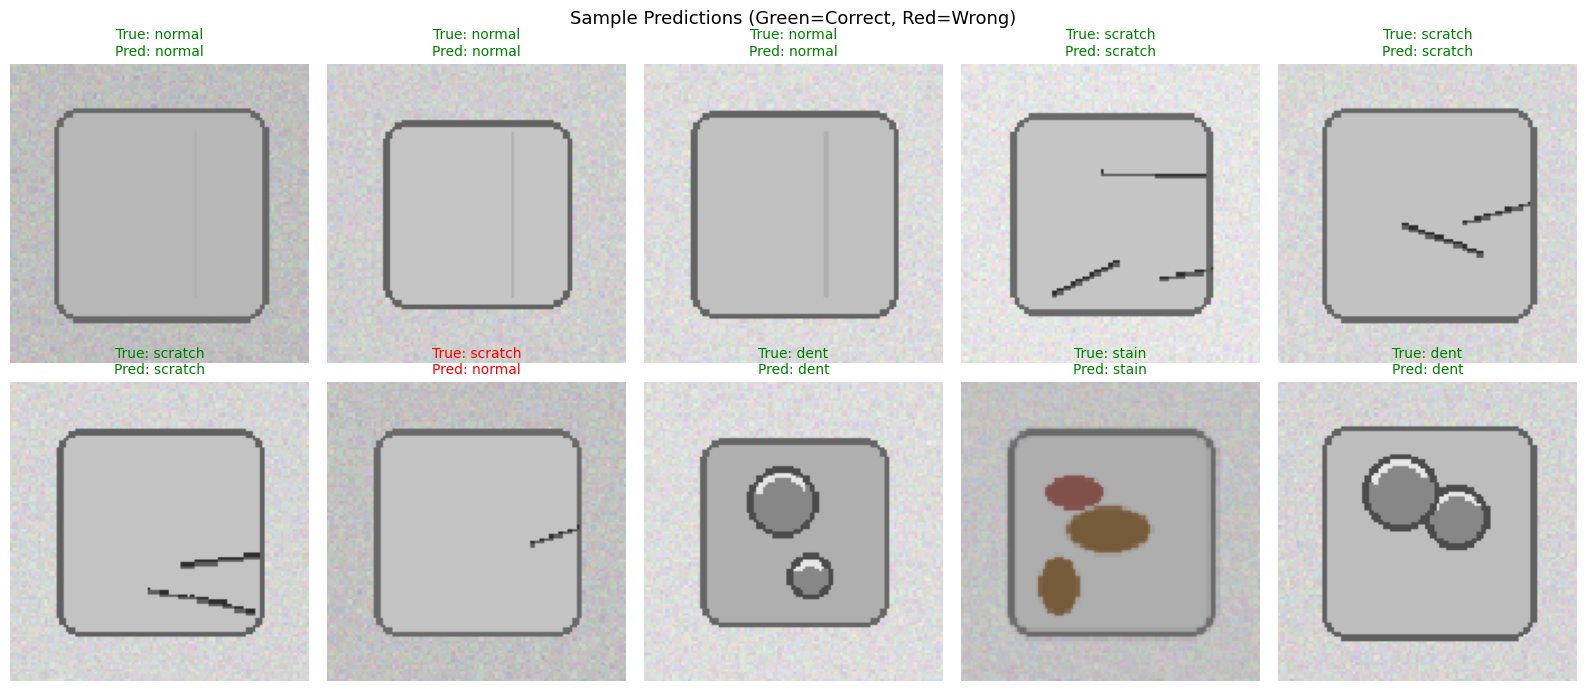

[Saved] /content/sample_predictions/prediction_outputs.png


In [34]:
# Sample predictions on test images
sample_images, sample_labels = next(
    val_test_datagen.flow_from_dataframe(
        test_df.sample(10, random_state=1),
        x_col='filepath', y_col='label',
        target_size=IMG_SIZE, batch_size=10,
        class_mode='categorical', shuffle=False
    )
)

preds      = model.predict(sample_images)
pred_idxs  = np.argmax(preds, axis=1)
true_idxs  = np.argmax(sample_labels, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i])
    pred_label = class_names[pred_idxs[i]]
    true_label = class_names[true_idxs[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label}",
                 color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/sample_predictions/prediction_outputs.png', dpi=150)
plt.show()
print("[Saved] /content/sample_predictions/prediction_outputs.png")